# Mutual Fund Analysis – Exploratory Data Analysis (EDA)

**Bluestock Internship**

**Prepared by:** Swetha S

---

## Objective

The objective of this notebook is to perform Exploratory Data Analysis (EDA) on the mutual fund datasets by analyzing NAV trends, investor transactions, AUM growth, category inflows, demographics, and portfolio characteristics. The insights generated will support dashboard development and business decision-making.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")

# Display plots in notebook
%matplotlib inline

In [2]:
# Load cleaned datasets

fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")

transactions = pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv")

performance = pd.read_csv("../data/processed/07_scheme_performance_cleaned.csv")

print("Datasets Loaded Successfully!")

print("Fund Master:", fund_master.shape)
print("NAV History:", nav.shape)
print("Transactions:", transactions.shape)
print("Performance:", performance.shape)

Datasets Loaded Successfully!
Fund Master: (40, 15)
NAV History: (46000, 3)
Transactions: (32778, 13)
Performance: (40, 19)


## NAV Trend Analysis

This chart shows the daily Net Asset Value (NAV) trend for all mutual fund schemes from 2022 onwards. It helps identify overall market movements and fund performance over time.

In [3]:
import plotly.express as px
import pandas as pd

# Convert date column
nav["date"] = pd.to_datetime(nav["date"])

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend of Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "NAV",
        "amfi_code": "AMFI Code"
    }
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.10,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.10,
    line_width=0,
    annotation_text="2024 Market Correction",
    annotation_position="top left"
)

fig.update_layout(
    template="plotly_white",
    height=650
)

fig.show()

In [4]:
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

print(aum.head())

print("\nColumns:")
print(aum.columns)

print("\nShape:")
print(aum.shape)

         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168

Columns:
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')

Shape:
(90, 5)


In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## AUM Growth by Fund House (2022–2025)

This grouped bar chart compares the Assets Under Management (AUM) of different fund houses over time. It highlights the growth of each fund house and emphasizes SBI Mutual Fund's market leadership.

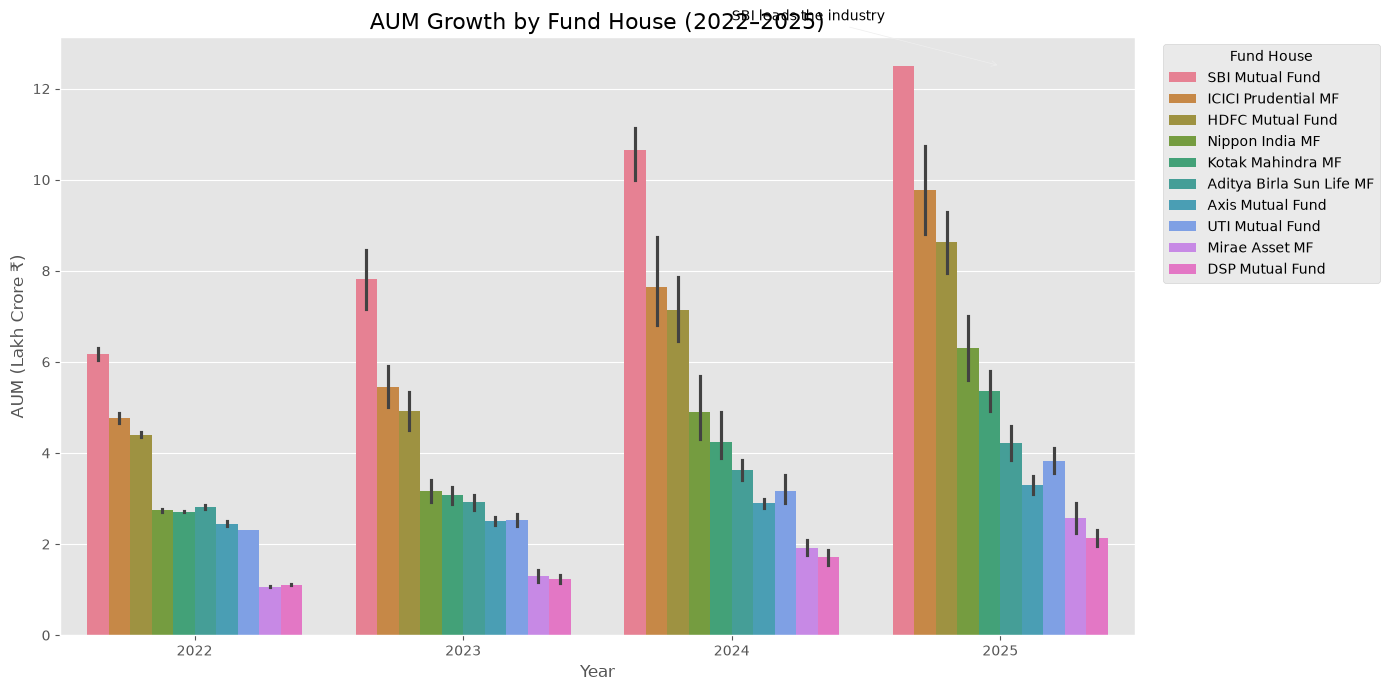

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

# Convert date to datetime
aum["date"] = pd.to_datetime(aum["date"])

# Extract year
aum["year"] = aum["date"].dt.year

# Plot
plt.figure(figsize=(14, 7))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore ₹)")
plt.xticks(rotation=0)

# Highlight SBI dominance
plt.annotate(
    "SBI leads the industry",
    xy=(3, 12.5),          # Approximate location
    xytext=(2, 13.5),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

plt.legend(title="Fund House", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

plt.show()

In [7]:
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

print(sip.head())

print("\nColumns:")
print(sip.columns)

print("\nShape:")
print(sip.shape)

     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   
3  2022-04             11863                       5.48   
4  2022-05             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  

Columns:
Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')

Shape:
(48, 6)


## Monthly SIP Inflow Trend (Jan 2022 – Dec 2025)

This interactive line chart shows the monthly SIP inflows into mutual funds from January 2022 to December 2025. The highest SIP inflow is highlighted to show the industry's growth.

In [8]:
import pandas as pd
import plotly.express as px

# Load dataset
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

# Convert month column to datetime
sip["month"] = pd.to_datetime(sip["month"])

# Create line chart
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (2022–2025)",
    labels={
        "month": "Month",
        "sip_inflow_crore": "SIP Inflow (₹ Crore)"
    }
)

# Find highest SIP inflow
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

# Highlight highest value
fig.add_scatter(
    x=[max_row["month"]],
    y=[max_row["sip_inflow_crore"]],
    mode="markers+text",
    text=[f'Peak: ₹{max_row["sip_inflow_crore"]:,} Cr'],
    textposition="top center",
    marker=dict(size=12, color="red"),
    name="Highest SIP"
)

fig.update_layout(
    template="plotly_white",
    height=600
)

fig.show()

In [9]:
category = pd.read_csv("../data/raw/05_category_inflows.csv")

print(category.head())

print("\nColumns:")
print(category.columns)

print("\nShape:")
print(category.shape)

     month         category  net_inflow_crore
0  2024-04        Large Cap            2413.0
1  2024-04          Mid Cap            3897.0
2  2024-04        Small Cap            3533.0
3  2024-04        Flexi Cap            4947.0
4  2024-04  Large & Mid Cap            4214.0

Columns:
Index(['month', 'category', 'net_inflow_crore'], dtype='str')

Shape:
(144, 3)


## Category-wise Net Inflow Heatmap

This heatmap visualizes the monthly net inflows across different mutual fund categories. Darker colors indicate higher investor inflows, helping identify popular categories over time.

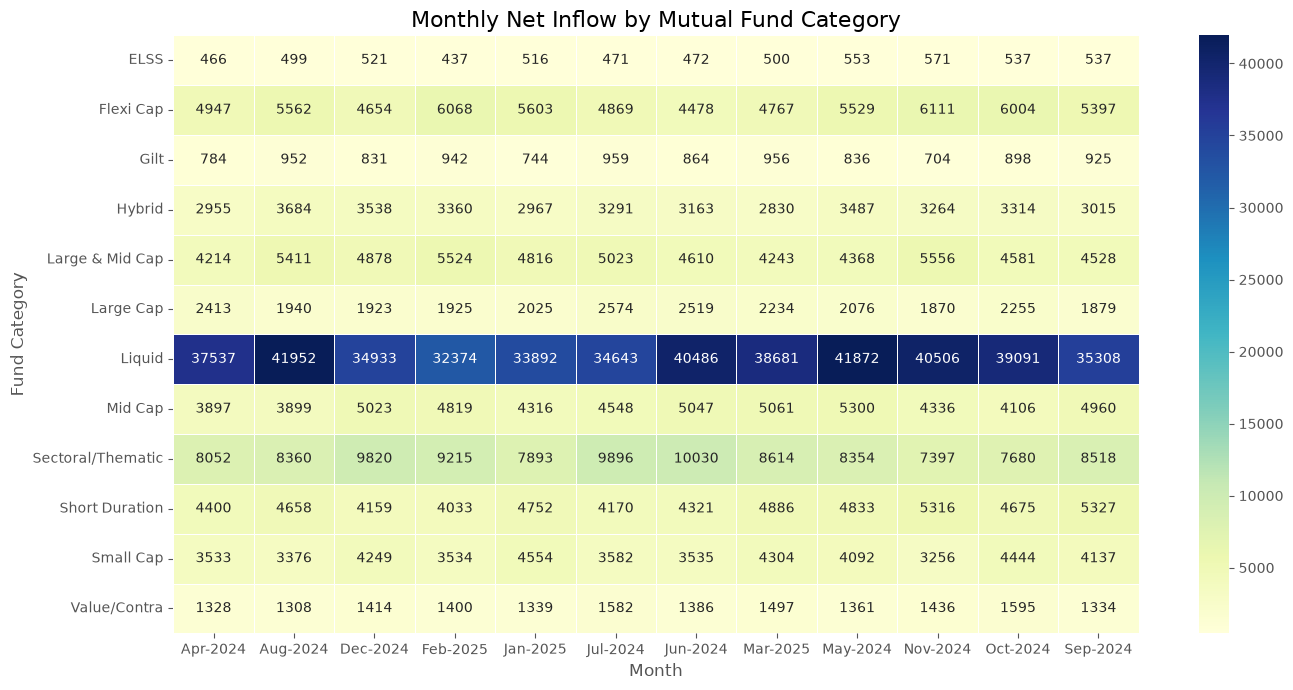

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
category = pd.read_csv("../data/raw/05_category_inflows.csv")

# Convert month to datetime
category["month"] = pd.to_datetime(category["month"])

# Convert month to Month-Year format
category["month"] = category["month"].dt.strftime("%b-%Y")

# Create pivot table
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

# Plot heatmap
plt.figure(figsize=(14, 7))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    linewidths=0.5
)

plt.title("Monthly Net Inflow by Mutual Fund Category", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()
plt.show()

## Investor Demographics

This section analyzes the demographic profile of mutual fund investors, including age group distribution, SIP investment patterns, and gender split.

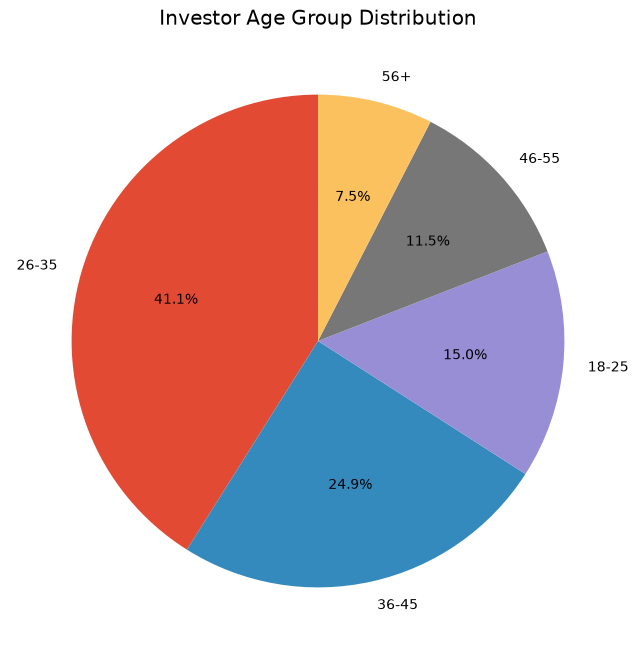

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned transactions
transactions = pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv")

# Count age groups
age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.show()

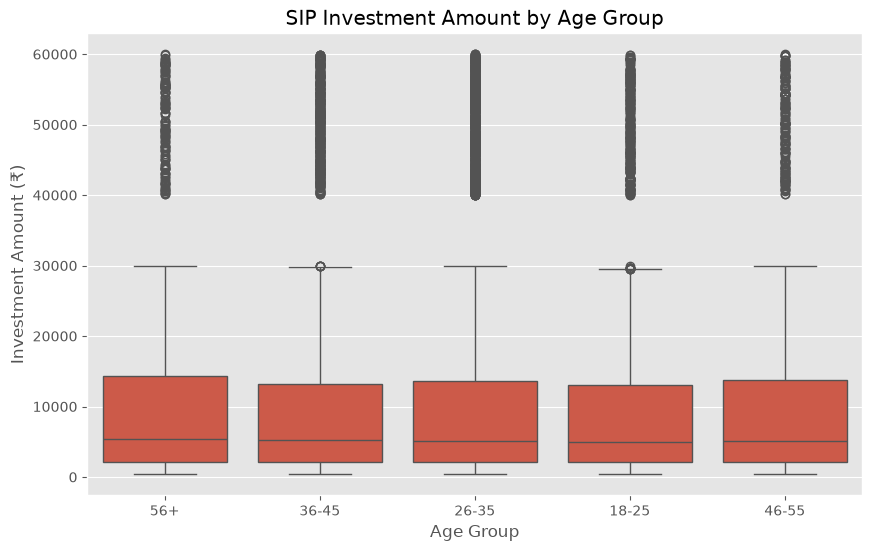

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter SIP transactions
sip_data = transactions[
    transactions["transaction_type"] == "SIP"
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_data,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Investment Amount by Age Group")

plt.xlabel("Age Group")

plt.ylabel("Investment Amount (₹)")

plt.show()

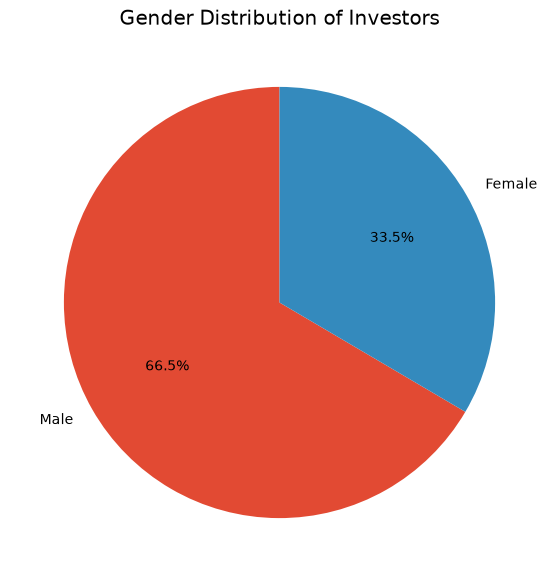

In [13]:
gender_counts = transactions["gender"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution of Investors")

plt.show()

## Geographic Distribution

This section analyzes the geographical distribution of investors by comparing SIP investments across states and city tiers (T30 vs B30).

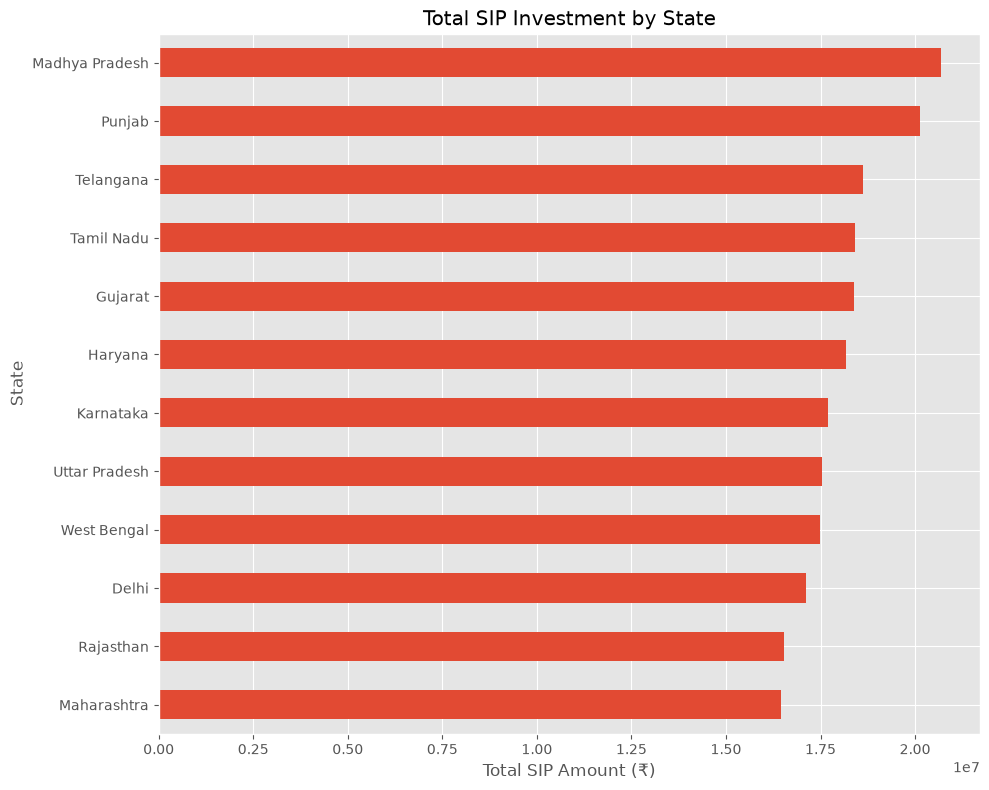

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

transactions = pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv")

# Filter SIP transactions
sip = transactions[transactions["transaction_type"] == "SIP"]

# Total SIP amount by state
state_data = (
    sip.groupby("state")["amount_inr"]
    .sum()
    .sort_values()
)

plt.figure(figsize=(10,8))

state_data.plot(kind="barh")

plt.title("Total SIP Investment by State")
plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

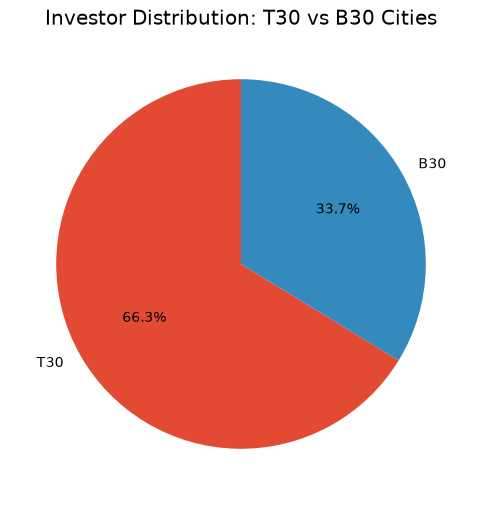

In [15]:
city_counts = transactions["city_tier"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    city_counts,
    labels=city_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Distribution: T30 vs B30 Cities")

plt.show()

In [16]:
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

print(folio.head())

print("\nColumns:")
print(folio.columns)

print("\nShape:")
print(folio.shape)

     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  

Columns:
Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')

Shape:
(21, 6)


## Industry Folio Count Growth

This chart illustrates the growth in mutual fund folio counts from 2022 to 2025, showing the increasing participation of investors in the mutual fund industry.

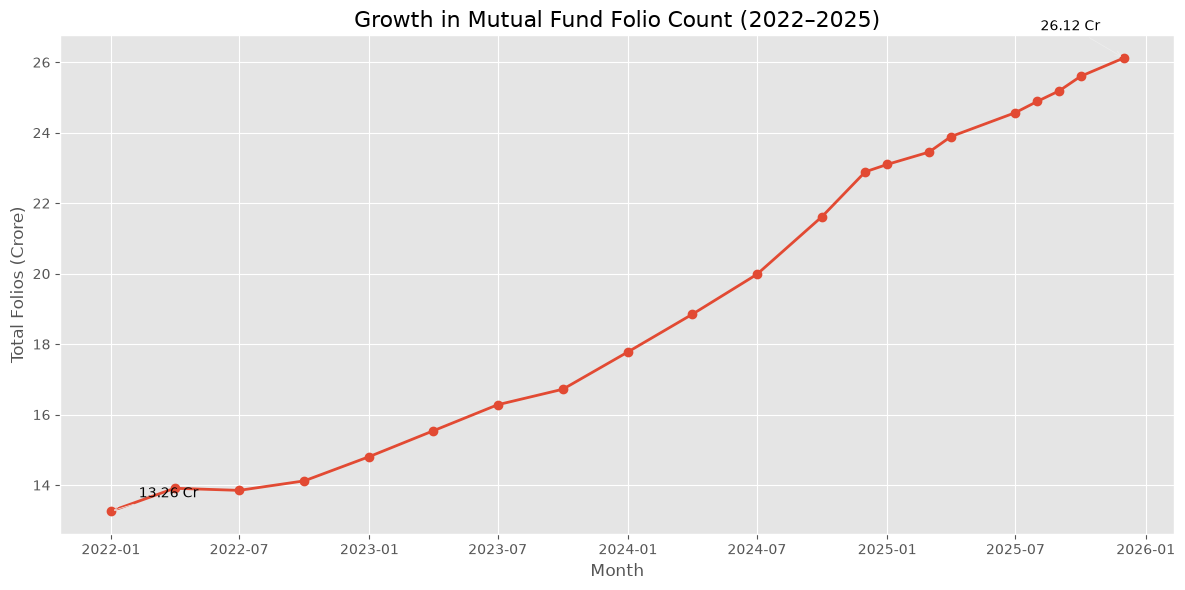

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

# Convert month to datetime
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o",
    linewidth=2
)

plt.title("Growth in Mutual Fund Folio Count (2022–2025)", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

# Mark starting point
plt.annotate(
    f'{folio.iloc[0]["total_folios_crore"]:.2f} Cr',
    xy=(folio.iloc[0]["month"], folio.iloc[0]["total_folios_crore"]),
    xytext=(20,10),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

# Mark ending point
plt.annotate(
    f'{folio.iloc[-1]["total_folios_crore"]:.2f} Cr',
    xy=(folio.iloc[-1]["month"], folio.iloc[-1]["total_folios_crore"]),
    xytext=(-60,20),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.grid(True)
plt.tight_layout()
plt.show()

## NAV Return Correlation Matrix

This heatmap shows the correlation between the daily returns of selected mutual fund schemes. Higher correlation indicates similar NAV movement patterns across funds.

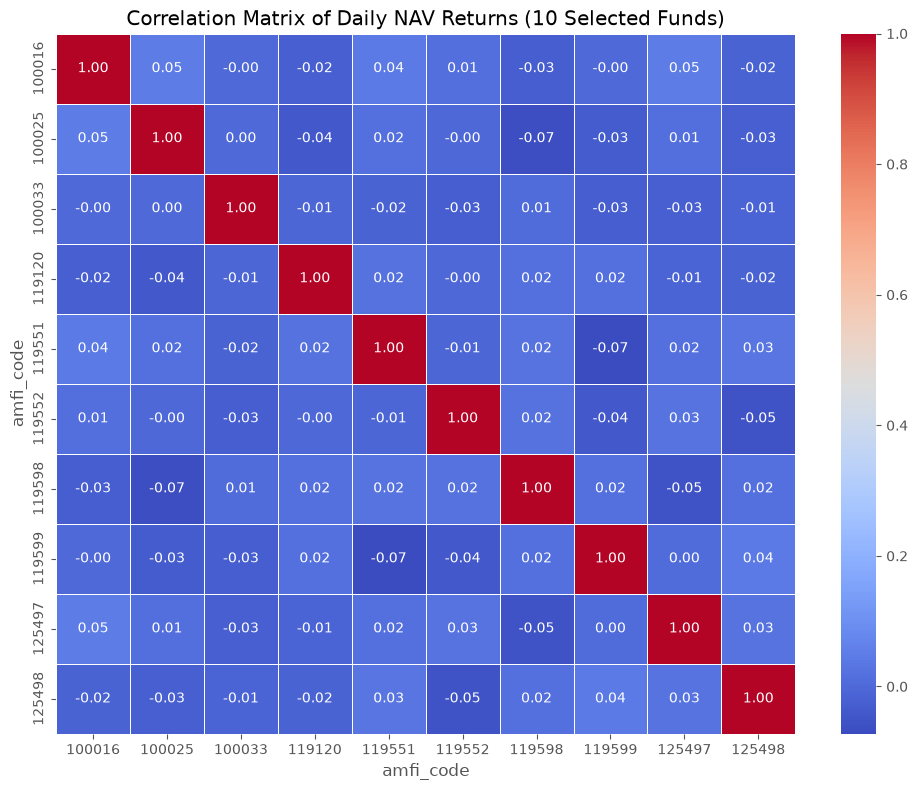

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load datasets
nav = pd.read_csv("../data/processed/02_nav_history_cleaned.csv")
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")

# Convert date
nav["date"] = pd.to_datetime(nav["date"])

# Select first 10 AMFI codes
selected_codes = fund_master["amfi_code"].head(10)

# Filter NAV data
nav_selected = nav[nav["amfi_code"].isin(selected_codes)]

# Pivot table
pivot = nav_selected.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

# Calculate daily returns
returns = pivot.pct_change().dropna()

# Correlation matrix
corr = returns.corr()

# Plot
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Matrix of Daily NAV Returns (10 Selected Funds)")

plt.tight_layout()

plt.show()

In [19]:
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print(portfolio.head())

print("\nColumns:")
print(portfolio.columns)

print("\nShape:")
print(portfolio.shape)

   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  

Columns:
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

Shape:
(322, 8)


## Sector Allocation Across Equity Mutual Funds

This donut chart shows the aggregate portfolio allocation across different sectors based on the holdings of all mutual fund schemes. It helps identify the sectors receiving the highest investment allocation.

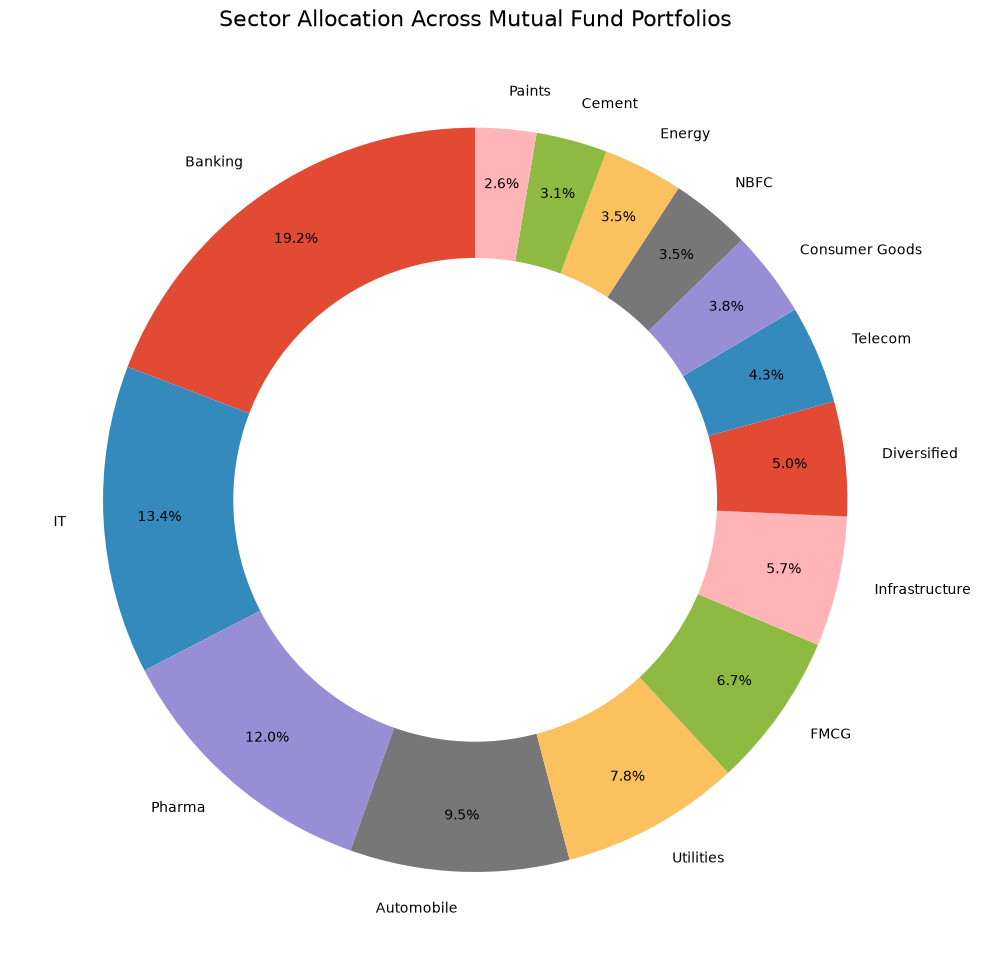

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

# Aggregate sector weights
sector_weights = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

# Plot Donut Chart
plt.figure(figsize=(10,10))

wedges, texts, autotexts = plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.85
)

# Create donut hole
centre_circle = plt.Circle((0,0),0.65,fc="white")
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sector Allocation Across Mutual Fund Portfolios", fontsize=16)

plt.tight_layout()
plt.show()

## Expense Ratio Distribution

This histogram shows how the expense ratios of mutual fund schemes are distributed.

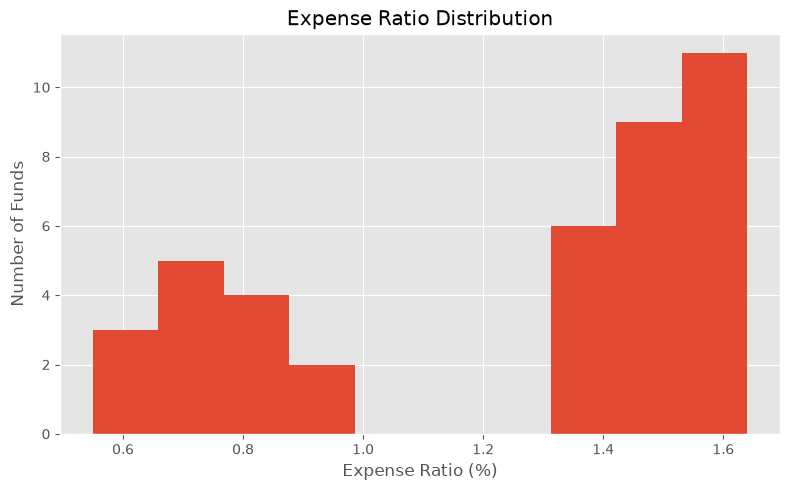

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(performance["expense_ratio_pct"], bins=10)

plt.title("Expense Ratio Distribution")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("Number of Funds")

plt.tight_layout()

plt.savefig("../reports/charts/expense_ratio_distribution.png", dpi=300)

plt.show()

## Risk Grade Distribution

Distribution of schemes based on their risk grade.

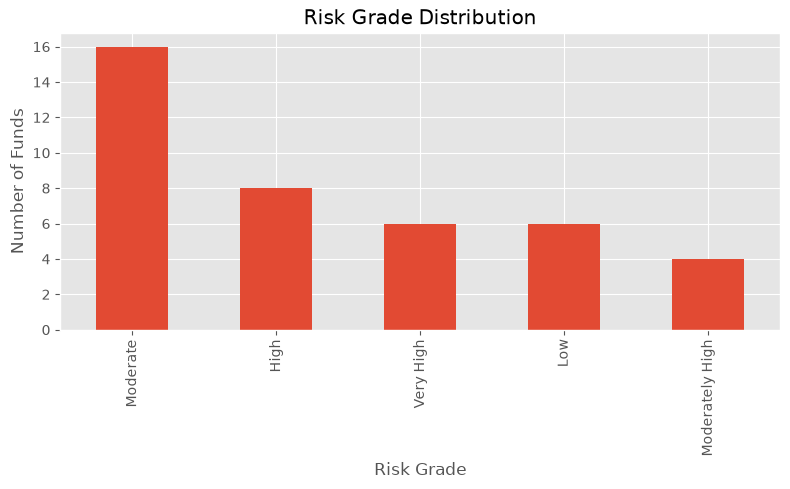

In [22]:
plt.figure(figsize=(8,5))

performance["risk_grade"].value_counts().plot(kind="bar")

plt.title("Risk Grade Distribution")
plt.xlabel("Risk Grade")
plt.ylabel("Number of Funds")

plt.tight_layout()

plt.savefig("../reports/charts/risk_grade_distribution.png", dpi=300)

plt.show()

## Top 10 Mutual Funds by AUM

Largest mutual fund schemes based on Assets Under Management.

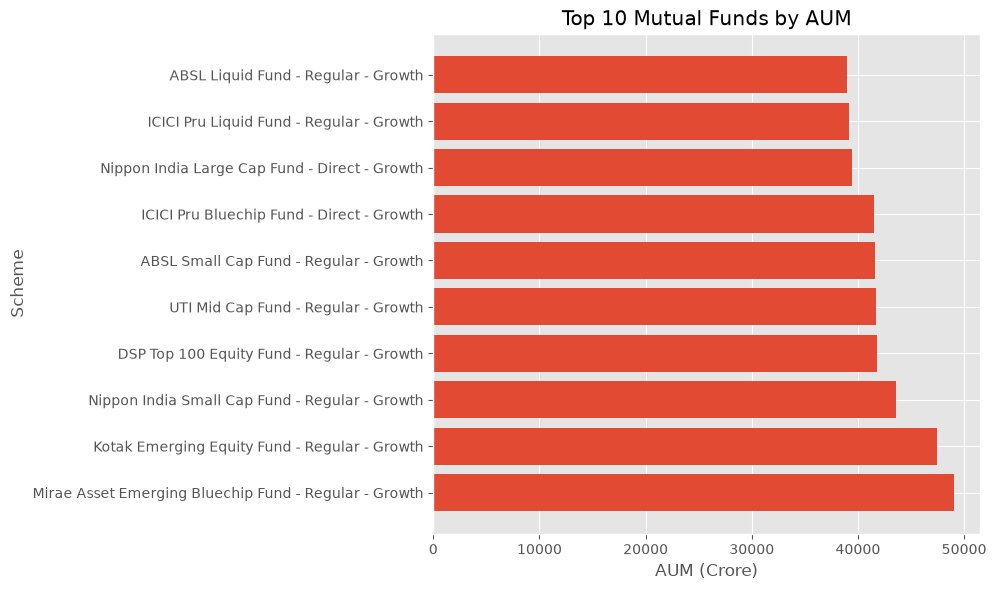

In [23]:
top10 = performance.sort_values(
    "aum_crore",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["scheme_name"],
    top10["aum_crore"]
)

plt.title("Top 10 Mutual Funds by AUM")
plt.xlabel("AUM (Crore)")
plt.ylabel("Scheme")

plt.tight_layout()

plt.savefig("../reports/charts/top10_aum.png", dpi=300)

plt.show()

## Morningstar Rating Distribution

Distribution of mutual fund schemes by Morningstar ratings.

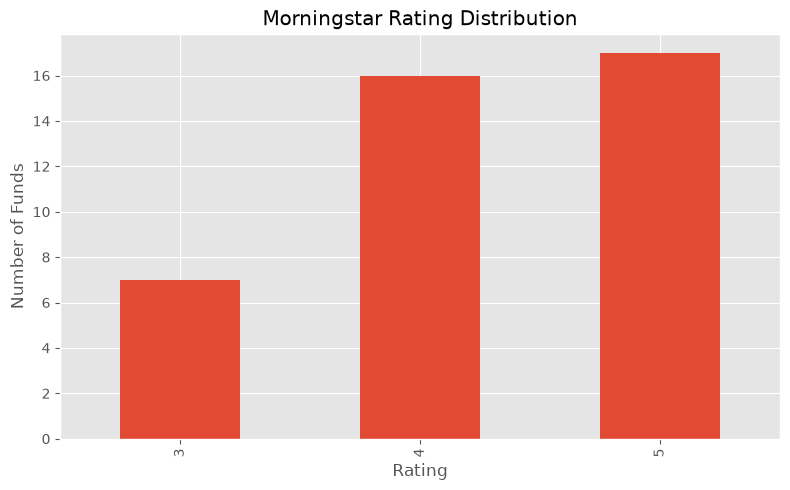

In [24]:
plt.figure(figsize=(8,5))

performance["morningstar_rating"].value_counts().sort_index().plot(kind="bar")

plt.title("Morningstar Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Funds")

plt.tight_layout()

plt.savefig("../reports/charts/morningstar_rating.png", dpi=300)

plt.show()

## Transaction Type Distribution

Distribution of SIP, Lumpsum, and Redemption transactions.

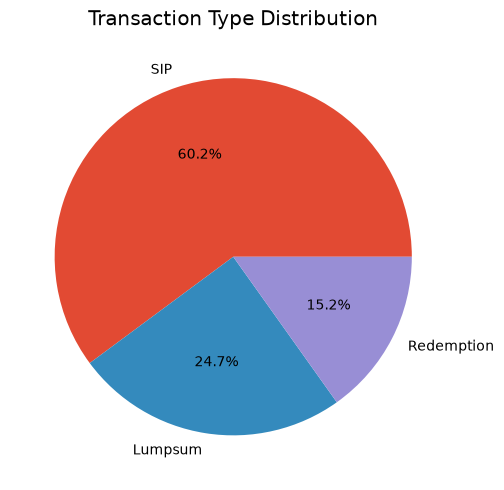

In [25]:
plt.figure(figsize=(7,5))

transactions["transaction_type"].value_counts().plot(kind="pie", autopct="%1.1f%%")

plt.ylabel("")

plt.title("Transaction Type Distribution")

plt.tight_layout()

plt.savefig("../reports/charts/transaction_type_distribution.png", dpi=300)

plt.show()

# Key EDA Findings

### 1.
The daily NAV of mutual fund schemes shows an overall upward trend, indicating long-term market growth.

### 2.
SBI Mutual Fund consistently maintains one of the highest Assets Under Management (AUM) among all fund houses.

### 3.
Monthly SIP inflows show steady growth, reflecting increasing investor confidence in mutual funds.

### 4.
Large Cap, Mid Cap, and Flexi Cap funds receive the highest monthly inflows.

### 5.
The majority of investors belong to the 26–45 age group.

### 6.
SIP investment amounts vary across different age groups, with some age groups investing significantly higher amounts.

### 7.
The gender distribution indicates active participation from both male and female investors.

### 8.
T30 cities contribute a larger share of mutual fund investments compared to B30 cities.

### 9.
The mutual fund industry has experienced consistent folio growth, indicating increasing retail participation.

### 10.
Sector allocation is concentrated in Banking, IT, Pharma, and other major sectors, reflecting diversified portfolio construction.

### 11.
Most mutual fund schemes have expense ratios within the expected industry range.

### 12.
Moderate and High risk funds make up a significant portion of the available schemes.

### 13.
A small number of mutual fund schemes account for a large share of total AUM.

### 14.
Morningstar ratings are concentrated between 3 and 5 stars, indicating generally good-performing funds.

### 15.
SIP transactions represent a significant portion of investor activity compared to other transaction types.

# Conclusion

The Exploratory Data Analysis provides valuable insights into mutual fund performance, investor behavior, fund house growth, portfolio allocation, and industry trends. The generated visualizations help identify investment patterns and form the foundation for the interactive dashboard and further predictive analytics.